# Generate Simulated Data

In [1]:
!pip install numpy mne nibabel glhmm scipy

  Using cached mne-1.11.0-py3-none-any.whl.metadata (15 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-2.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached igraph-1.0.0-cp39-abi3-macosx_11_0_arm64.whl.metadata (4.4 kB)
  Using cached nilearn-0.12.1-py3-none-any.whl.metadata (9.9 kB)
  Using cached texttable-1.7.0-py2.py3-none-any.whl.metadata (9.8 kB)
  Using cached imageio-2.37.2-py3-none-any.whl.metadata (9.7 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached mne-1.11.0-py3-none-any.whl (7.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 73.1 MB/s  0:00:00
Using cached igraph-1.0.0-cp39-abi3-macosx_11_0_arm64.whl (2.0 MB)
Using cached texttable-1.7.0-py2.py3-none-any.whl (10 kB)
Using cached nilearn-0.12.1-py3-none-any.whl (12.7 MB)
Using cached pandas-2.3.3-cp312-cp312-macosx_11_0_arm64.whl (10.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 85.9 MB/s  0:00:00
Us

### Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from glhmm import glhmm, preproc, utils, graphics, spectral, io, statistics, auxiliary
import os
import pickle
import sys
import pip
import mne
from mne.datasets import sample
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

# Logging levels, set to lowest
mne.set_log_level(verbose=40)

print(__doc__)

Automatically created module for IPython interactive environment


### Data Generation Params

We follow the beginning under the provided example by Maksymenko [here](https://mne.tools/stable/auto_examples/simulation/source_simulator.html).


In [3]:
# We use the provided sample subject
data_path = sample.data_path()
subjects_dir = data_path / "subjects"
subject = "sample"

evoked_fname = data_path / "MEG" / subject / "sample_audvis-ave.fif"
info = mne.io.read_info(evoked_fname)
tstep = 1.0 / info["sfreq"]

fwd_fname = data_path / "MEG" / subject / "sample_audvis-meg-eeg-oct-6-fwd.fif"
fwd = mne.read_forward_solution(fwd_fname)
src = fwd["src"]

In [4]:
# Creates a list of sample states based on a transition matrix to be used for the data generation
def sample_states(n_times, trans_mat, start_prob):
    K = trans_mat.shape[0]
    states = np.zeros(n_times, dtype=int)
    states[0] = np.random.choice(K, p=start_prob)
    for t in range(1, n_times):
        states[t] = np.random.choice(K, p=trans_mat[states[t-1]])
    return states

In [5]:
# Generate the waveform used to create the simulated dataset. Only allows for 2 additional states
def generate_state_waveforms(state_labels, sfreq, alpha_freq=10, gamma_freq=40):
    n_times = len(state_labels)
    times = np.arange(n_times) / sfreq

    # The baseline state. We arbitrarily assign a one degree lower amplitude compared to the other states.
    baseline = 2e-9 * np.random.randn(n_times)
    alpha = np.sin(2.0 * np.pi * alpha_freq * times) * 2e-8
    gamma = np.sin(2.0 * np.pi * gamma_freq * times) * 1e-8

    waveform = baseline.copy()
    waveform[state_labels==1] += alpha[state_labels==1]
    waveform[state_labels==2] += gamma[state_labels==2]

    return waveform

In [6]:
def simulate_one_dataset(
    fwd, src, info,
    alpha_label, gamma_label,
    duration=120,
    noise_scale=0.3,
    save_dir="simulations",
    sim_id=0
):
    sfreq = info["sfreq"]
    n_times = int(sfreq * duration)

    # Transition matrix per sample. This allows for each state to last for roughly ~20 ms given the sampling rate.
    trans_mat = np.array([
        [0.99, 0.005, 0.005], # Baseline
        [0.005, 0.99, 0.005], # Alpha
        [0.005, 0.005, 0.99] # Gamma
    ])

    # Start at baseline always
    start_prob = [1.0, 0.0, 0.0]
    state_labels = sample_states(n_times, trans_mat, start_prob)

    waveform = generate_state_waveforms(state_labels, sfreq)
    events = np.array([[0, 0, 1]])
    simulator = mne.simulation.SourceSimulator(src, tstep=1/sfreq)

    # Add alpha data only when state == 1
    alpha_wave = waveform * (state_labels == 1)
    simulator.add_data(alpha_label, alpha_wave, events)

    # Add gamma data only when state == 2
    gamma_wave = waveform * (state_labels == 2)
    simulator.add_data(gamma_label, gamma_wave, events)

    # Baseline: no region added (just sensor noise later)
    raw = mne.simulation.simulate_raw(info, simulator, forward=fwd)

    cov = mne.make_ad_hoc_cov(raw.info)
    cov_light = cov.copy()
    cov_light['data'] *= noise_scale**2
    mne.simulation.add_noise(raw, cov_light, iir_filter=[0.2, -0.2, 0.04])

    sim_path = os.path.join(save_dir, f"sim_{sim_id:03d}")
    os.makedirs(sim_path, exist_ok=True)

    raw.save(os.path.join(sim_path, "raw.fif"), overwrite=True)
    np.save(os.path.join(sim_path, "state_labels.npy"), state_labels)

    return raw, state_labels

### Test on a single data generation. Be sure to delete this from the folder after running it

In [7]:
alpha_label = mne.read_labels_from_annot(subject, regexp='pericalcarine-lh', subjects_dir=subjects_dir)[0]
gamma_label = mne.read_labels_from_annot(subject, regexp='precentral-rh', subjects_dir=subjects_dir)[0]

raw, labels = simulate_one_dataset(
      fwd=fwd,
      src=src,
      info=info,
      alpha_label=alpha_label,
      gamma_label=gamma_label,
      sim_id=99,
      duration=60,     # seconds
  )

### Generate dataset with 4 data points

In [8]:
def generate_multiple_datasets(fwd, src, info,n_simulations=4,save_dir="simulations"):
    alpha_label = mne.read_labels_from_annot(subject, regexp='pericalcarine-lh', subjects_dir=subjects_dir)[0]
    gamma_label = mne.read_labels_from_annot(subject, regexp='precentral-rh', subjects_dir=subjects_dir)[0]

    for i in range(n_simulations):
        print(f"Simulating dataset {i+1}/{n_simulations}...")
        simulate_one_dataset(
            fwd=fwd,
            src=src,
            info=info,
            alpha_label=alpha_label,
            gamma_label=gamma_label,
            sim_id=i,
            save_dir=save_dir,
            duration=120,     # seconds
        )

    print("All simulations completed.")

In [11]:
generate_multiple_datasets(fwd=fwd, src=src, info=info, n_simulations=4)


Simulating dataset 1/4...
Simulating dataset 2/4...
Simulating dataset 3/4...
Simulating dataset 4/4...
All simulations completed.


### Plot for sanity check

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/mne/viz/_figure.py:384: RuntimeWarning: divide by zero encountered in matmul
  data = self.mne.projector @ data
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/mne/viz/_figure.py:384: RuntimeWarning: overflow encountered in matmul
  data = self.mne.projector @ data
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/mne/viz/_figure.py:384: RuntimeWarning: invalid value encountered in matmul
  data = self.mne.projector @ data


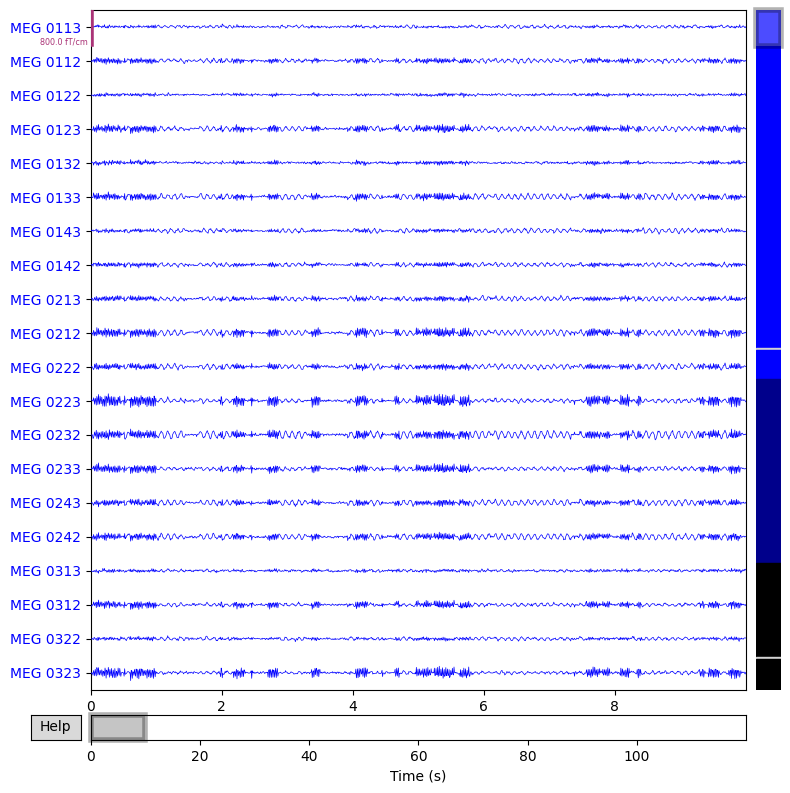

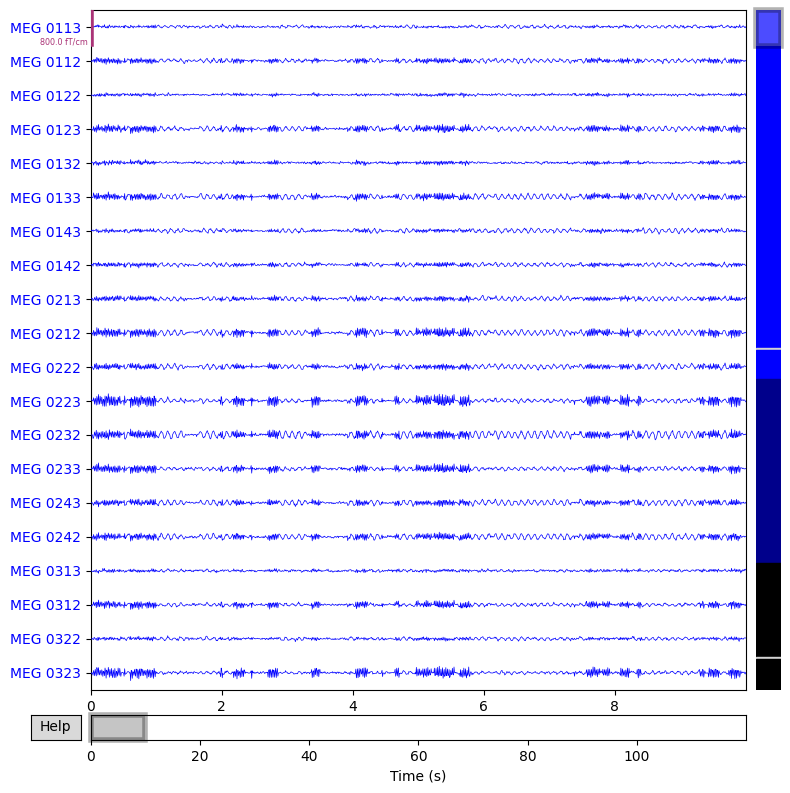

In [12]:
raw = mne.io.read_raw_fif('simulations/sim_000/raw.fif')
raw.plot()

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


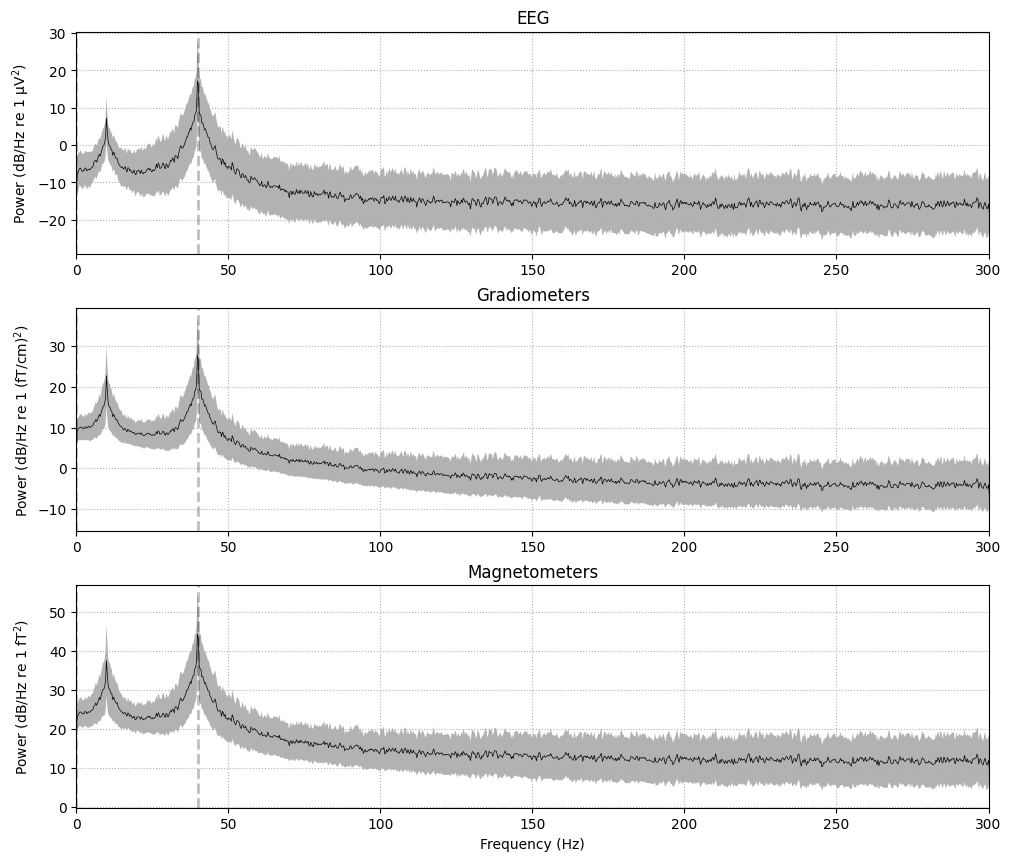

In [13]:
# Should have spike at 40 hz and 10 hz
spectrum = raw.compute_psd()
spectrum.plot(average=True, picks="data", exclude="bads", amplitude=False)

# Train TDE-HMM

In [14]:
# X_list is a 2D array where each internal list is the data for each simulation
# Y_list is a 2D array where each internal list is the corresponding ground-truth states for each simulation

def load_simulated_meg_for_hmm(sim_root="simulations"):
    X_list = []
    y_list = []

    sim_dirs = sorted(d for d in os.listdir(sim_root) if d.startswith("sim_"))

    for sim in sim_dirs:
        raw_path = f"{sim_root}/{sim}/raw.fif"
        label_path = f"{sim_root}/{sim}/state_labels.npy"

        raw = mne.io.read_raw_fif(raw_path, preload=True, verbose=False)
        first_20 = raw.ch_names[:20]
        raw.pick(first_20)

        orig_n = raw.n_times
        raw.resample(300)
        X_raw = raw.get_data().T
        new_n = X_raw.shape[0]

        labels = np.load(label_path)
        idx = (np.arange(new_n) * (orig_n / new_n)).astype(int)
        idx = np.clip(idx, 0, orig_n-1)
        labels_rs = labels[idx]

        X_list.append(X_raw)
        y_list.append(labels_rs)

    return X_list, y_list


In [15]:
X_list, y_list = load_simulated_meg_for_hmm()

In [16]:
# Concatenate everything and use the index data to keep track
X_concat = np.vstack(X_list) #simulation
y_concat = np.hstack(y_list) #state labels

In [17]:
idx_data = statistics.get_indices_from_list(X_list)

In [18]:
X_preproc = preproc.preprocess_data(X_concat, idx_data)[0]

### Sanity check plot

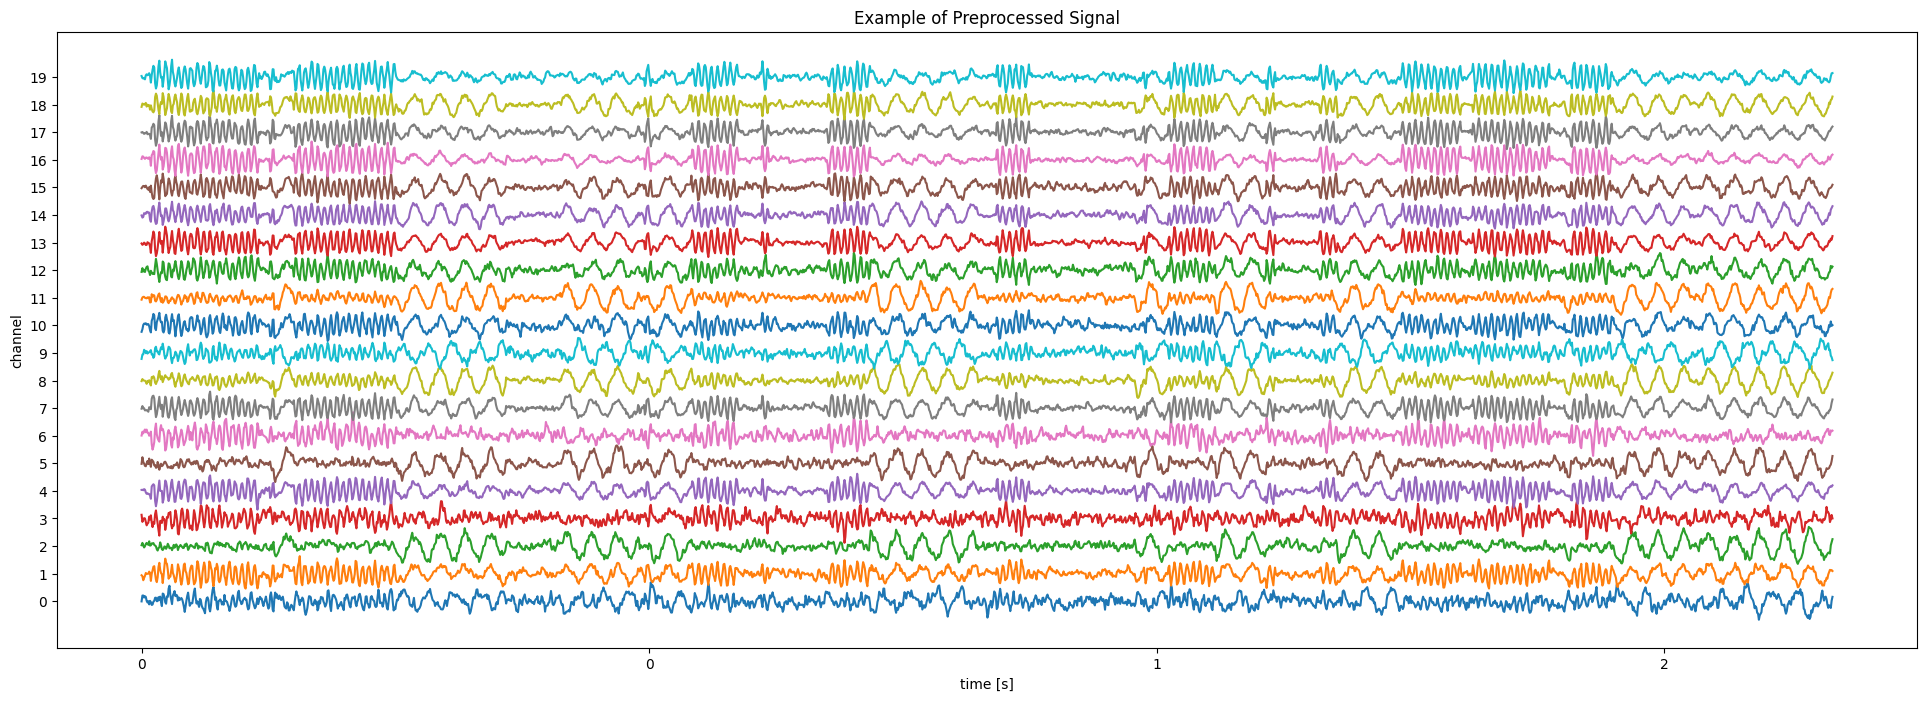

In [19]:
plot_range = np.arange(0, 2000)

Fs = info['sfreq']
tick_positions = np.arange(0, len(plot_range), int(Fs))
tick_labels = (tick_positions / Fs).astype(int)
n_regions = X_preproc.shape[1]

# plot each parcel separately
plt.close('all')
fig = plt.figure(figsize=(24,8))
for i in range(n_regions):
    plt.plot(X_preproc[plot_range,i]+i*5)

plt.xticks(tick_positions, tick_labels)
plt.xlabel('time [s]')
plt.yticks(np.arange(0,n_regions*5,5),np.arange(n_regions))
plt.ylabel('channel')
plt.title('Example of Preprocessed Signal')
plt.show()

### Apply TDE preprocessing


In [20]:
S = 1
L = 2
lags = np.arange(-L, L + 1, S)

X_embedded, idx_tde, pca_model = preproc.build_data_tde(X_preproc,idx_data,lags=lags, pca=2 * 20)

# Since we messed up X_preproc with this embedding stuff
# we need to fix the ground-truth labels to match correctly
# for when we calculate/compare with the ground truth
y_tde_list = []
for (s_tde, e_tde) in idx_tde:
    y_tde_list.append(y_concat[s_tde:e_tde])

y_tde = np.concatenate(y_tde_list)

assert len(y_tde) == X_embedded.shape[0], (f"Label mismatch: y={len(y_tde)}, X={X_embedded.shape[0]}")

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/decomposition/_base.py:155: RuntimeWarning: divide by zero encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components_.T
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/decomposition/_base.py:155: RuntimeWarning: overflow encountered in matmul
  X_transformed -= xp.reshape(self.mea

In [21]:
TDE_hmm = glhmm.glhmm(model_beta='no', model_mean='state', K=3, covtype='full')

In [22]:
# train HMM
print('Training HMM-TDE')
stc_tde, xi_tde, fe_tde = TDE_hmm.train(X=None, Y=X_embedded, indices=idx_tde)
vpath_tde = TDE_hmm.decode(X=None, Y=X_embedded, viterbi=True)

Training HMM-TDE


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: divide by zero encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: overflow encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: invalid value encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glhmm.py:822: RuntimeWarning: divide by zero encountered in matmul
  GY = np.expand_dims(Gm[:,k],axis=1).T @ Yr
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glhmm.py:822: RuntimeWarning: overflow encountered in matmul
  GY = np.expand_dims(Gm[:,k],axis=1).T @ Yr
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glh

Init repetition 1 free energy = 9128009.06732127


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: divide by zero encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: overflow encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: invalid value encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glhmm.py:371: RuntimeWarning: divide by zero encountered in matmul
  else: Cd = d @ C
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glhmm.py:371: RuntimeWarning: overflow encountered in matmul
  else: Cd = d @ C
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glhmm.py:371: RuntimeWarning: invalid value encountered

Init repetition 2 free energy = 9128053.570614096


...

Cycle 11, free energy = 9069056.363445276, relative change = 6.718212240693119e-10


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:430: RuntimeWarning: divide by zero encountered in matmul
  D = 0.5 * (t1 - t2 - N + np.trace(isigma_p @ sigma_q) + ((d.T @ isigma_p) @ d))
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:430: RuntimeWarning: overflow encountered in matmul
 

Cycle 12, free energy = 9069056.363445273, relative change = 1.0335711138459606e-10


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:430: RuntimeWarning: divide by zero encountered in matmul
  D = 0.5 * (t1 - t2 - N + np.trace(isigma_p @ sigma_q) + ((d.T @ isigma_p) @ d))
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:430: RuntimeWarning: overflow encountered in matmul
 

Cycle 13, free energy = 9069056.36344527, relative change = 5.1678555689627355e-11
Reached early convergence
Finished training in 38.19s : active states = 3


### Save the trained TDE-HMM

In [23]:
hmm_dict = {
    'hmm':TDE_hmm,
    'stc':stc_tde,
    'xi':xi_tde,'fe':fe_tde,'vpath':vpath_tde}
with open("./hmm_tde.pkl", "wb") as fp:
    pickle.dump(hmm_dict, fp, pickle.HIGHEST_PROTOCOL)

### Sanity check view the Viterbi path

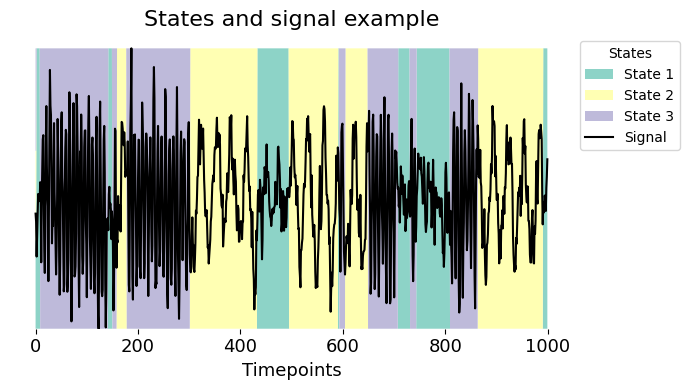

In [24]:
# apply the padGamma function to the vp to plot states and signal
T = auxiliary.get_T(idx_data)
options_tde = {'embeddedlags':list(lags)}
paddedVP = auxiliary.padGamma(vpath_tde, T, options_tde)

# plot state time courses with signal
plotting_range = np.arange(0, 1000)
graphics.plot_vpath(paddedVP[plotting_range], signal=X_preproc[plotting_range,1].copy(), title="States and signal example")

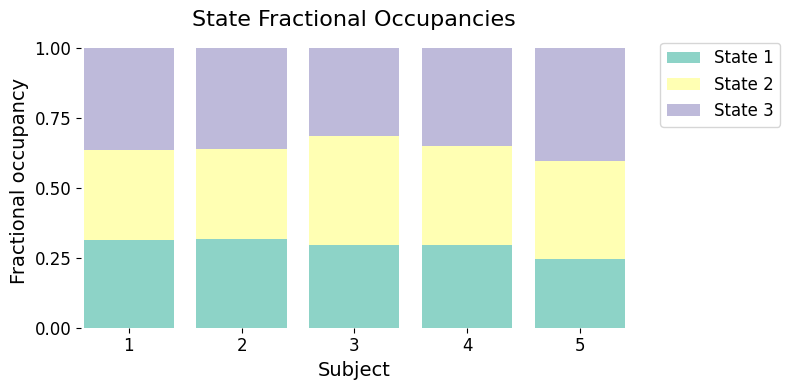

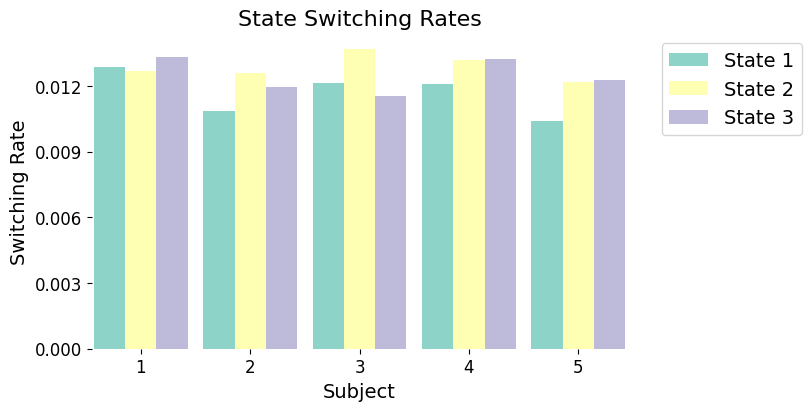

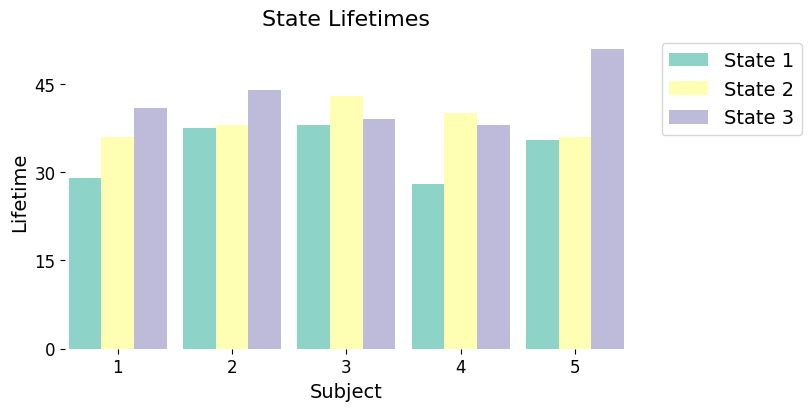

In [25]:
# inspect states - basic sanity checks
FO = utils.get_FO(stc_tde, indices=idx_tde)
SR = utils.get_switching_rate(stc_tde, indices=idx_tde)
LTmean, LTmed, LTmax = utils.get_life_times(vpath_tde, indices=idx_tde)

# plot some relevant statistics
graphics.plot_FO(FO)
graphics.plot_switching_rates(SR)
graphics.plot_state_lifetimes(LTmed)

### Verify HMM w/ Ground Truths

In [26]:
row_sums = vpath_tde.sum(axis=1)
assert np.allclose(row_sums, 1.0), "Some rows are not proper one-hot vectors!"

z = np.argmax(vpath_tde, axis=1).astype(int)

In [27]:
n_states = vpath_tde.shape[1]  # 3

#hungarian match
C = confusion_matrix(y_tde, z, labels=range(n_states))
C_pred_true = C.T

cost = -C_pred_true
row_ind, col_ind = linear_sum_assignment(cost)
mapping = dict(zip(row_ind, col_ind))
print("HMM -> True mapping:", mapping)
#end of matching

z_mapped = np.vectorize(lambda s: mapping[s])(z)

C_mapped = confusion_matrix(y_tde, z_mapped, labels=range(n_states))
print("Mapped confusion matrix (true rows, predicted cols):")
print(C_mapped) #diagnoal: # of correct state predictions
#other cells: # of wrong state predictions (all after Hungarian Match performed)

accuracy = (z_mapped == y_tde).mean()
print(f"Accuracy after mapping: {accuracy:.3f}")

HMM -> True mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
Mapped confusion matrix (true rows, predicted cols):
[[42698  5204  5092]
 [ 3077 47387  5332]
 [ 2779  3601 46810]]
Accuracy after mapping: 0.845


### Plot Histogram to Compare Distribution of States

In [31]:
#extract run durations for each state
def get_run_lengths(seq):
    seq = np.asarray(seq)
    run_lengths = {s: [] for s in np.unique(seq)}

    current_state = seq[0]
    length = 1

    for a, b in zip(seq[:-1], seq[1:]):
        if a == b:
            length += 1
        else:
            run_lengths[current_state].append(length)
            current_state = b
            length = 1
    run_lengths[current_state].append(length)

    return run_lengths

def convert_to_seconds(run_dict, Fs=300):
    return {k: np.array(v) / Fs for k, v in run_dict.items()}

true_runs = get_run_lengths(y_tde)
pred_runs = get_run_lengths(z_mapped)

true_sec = convert_to_seconds(true_runs, Fs=Fs)
pred_sec = convert_to_seconds(pred_runs, Fs=Fs)

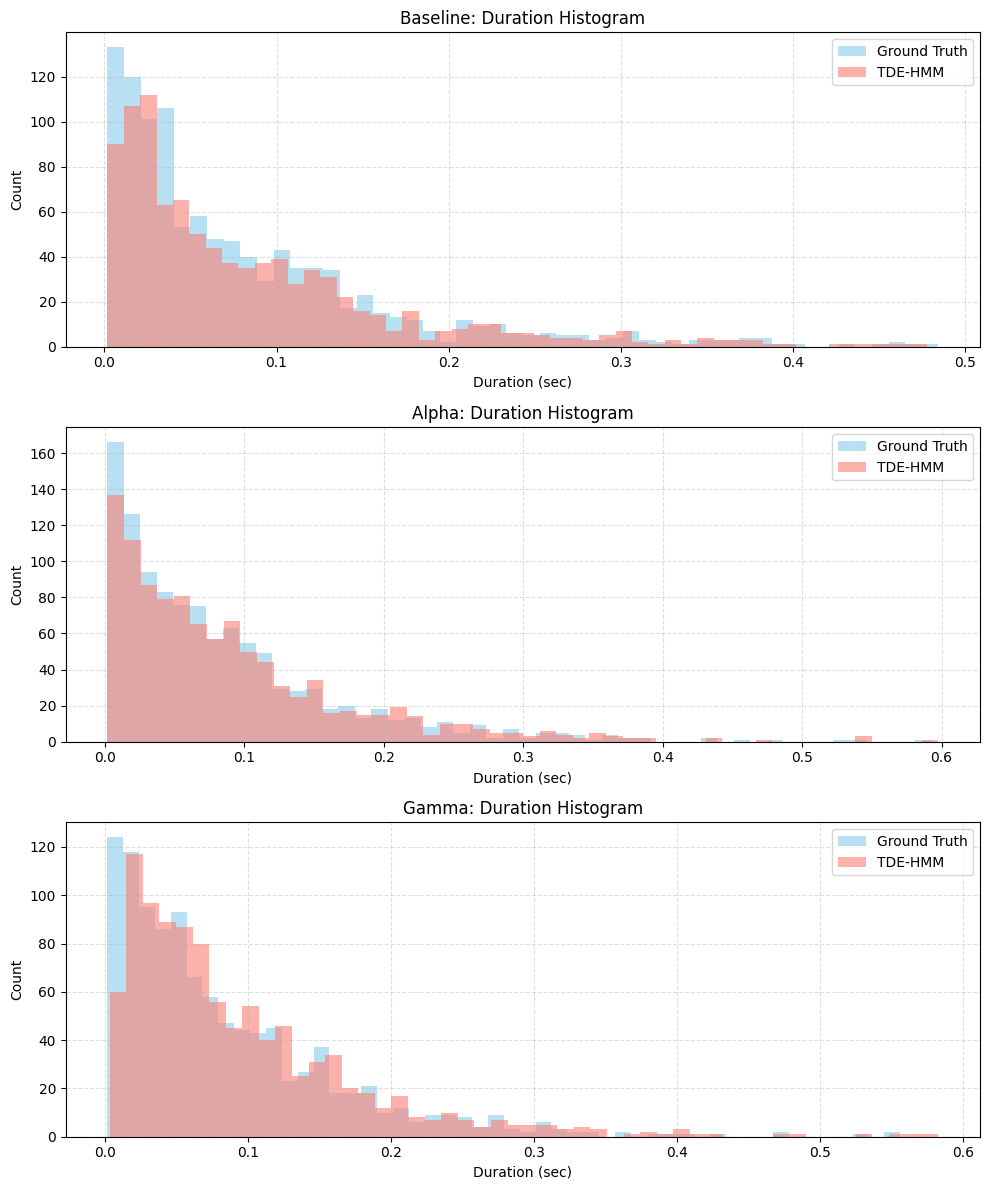

In [32]:
def plot_hist_duration(true_sec, pred_sec, bins=50):

    # Map numeric states → meaningful labels
    state_names = {
        0: "Baseline",
        1: "Alpha",
        2: "Gamma"
    }

    states = sorted(true_sec.keys())  # e.g., [0,1,2]

    fig, ax = plt.subplots(len(states), 1, figsize=(10, 4*len(states)))

    if len(states) == 1:
        ax = [ax]

    for i, s in enumerate(states):

        # Plot histogram of true durations
        ax[i].hist(
            true_sec[s], bins=bins, alpha=0.6,
            label="Ground Truth", color="skyblue"
        )

        # Plot histogram of HMM-predicted durations
        ax[i].hist(
            pred_sec[s], bins=bins, alpha=0.6,
            label="TDE-HMM", color="salmon"
        )

        # Use meaningful state name instead of numeric ID
        ax[i].set_title(f"{state_names[s]}: Duration Histogram")
        ax[i].set_xlabel("Duration (sec)")
        ax[i].set_ylabel("Count")
        ax[i].legend()
        ax[i].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_hist_duration(true_sec, pred_sec, bins=50)

### Plot heapmap for Confusion Matrix

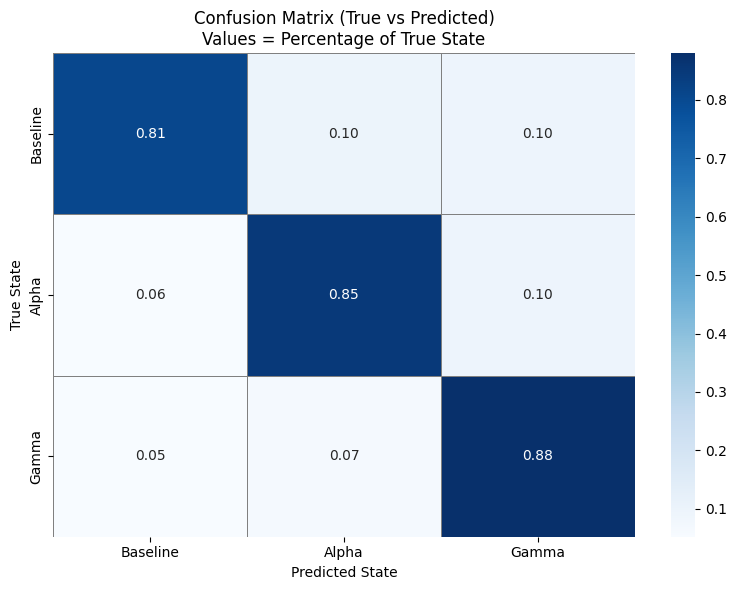

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_heatmap(C_mapped):
    # Convert counts → percentages
    C_pct = C_mapped / C_mapped.sum(axis=1, keepdims=True)

    # State name mapping
    state_names = ["Baseline", "Alpha", "Gamma"]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        C_pct,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=state_names,
        yticklabels=state_names,
        linewidths=0.5,
        linecolor='gray'
    )

    plt.title("Confusion Matrix (True vs Predicted)\nValues = Percentage of True State")
    plt.xlabel("Predicted State")
    plt.ylabel("True State")
    plt.tight_layout()
    plt.show()

plot_confusion_heatmap(C_mapped)

### The End